# Classificação Utilizando EuRepoC dataset

##  Previsão de Ciberataques com Inteligência Artificial (K-NN)
**Análise e Modelagem Preditiva usando a base de dados do EuRepoC**

Este projeto tem como objetivo analisar incidentes cibernéticos globais e construir um modelo de Machine Learning capaz de classificar e prever o Tipo de Incidente (ex: Data theft, Disruption, Hijacking) com base nas características do ataque, como país de origem, tipo de alvo e método de atribuição.


## Importação das Libs e Carregamento dos dados

In [130]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

print("Bibliotecas carregadas")

from google.colab import files

try:
  dataset = pd.read_csv('/content/eurepoc_global_database_1.3.csv')
  print(f"Tamanho original da base: {dataset.shape}")
  display(dataset.head())
except Exception as e:
  print(f'Error reading file "{dataset}": {e}')

A saída de streaming foi truncada nas últimas 5000 linhas.
780   https://www.allgaeuer-zeitung.de/allgaeu/kaufb...  2023-06-29   
781   https://www.vrt.be/vrtnws/nl/2023/06/27/cybera...  2023-06-28   
782   https://www.vzsar.ru/news/2023/06/23/ddosataka...  2023-06-28   
783   https://www.marketscreener.com/quote/stock/VIR...  2023-06-28   
784   https://www.centrobasile.it/; https://www.cent...  2023-06-28   
785   https://www.dailysentinel.com/social_media/hac...  2023-06-27   
786   https://www.ville-bouchemaine.fr/actualites/in...  2023-06-27   
787   https://www.sudouest.fr/faits-divers/le-chu-de...  2023-06-27   
788   https://therecord.media/fort-worth-cyberattack...  2023-06-27   
789   https://therecord.media/canadian-oil-giant-sun...  2023-06-27   
790   https://www.govinfosecurity.com/victim-count-i...  2023-06-27   
791   https://www.rnd.de/politik/angriff-auf-spd-mai...  2023-06-27   
792   https://www.bleepingcomputer.com/news/security...  2023-06-26   
793   https://ther

## Análise dos dados coletados

Antes de aplicar qualquer modelo matemático, precisamos entender o comportamento das ameaças ao longo do tempo.

As visualizações abaixo respondem a duas perguntas cruciais:
1. O volume de ciberataques está crescendo com o passar dos anos?
2. Quais são as tendências atuais? (Ex: Houve uma explosão recente de Roubo de Dados ou Interrupção de Sistemas?)




Gerando visualizações exploratórias...


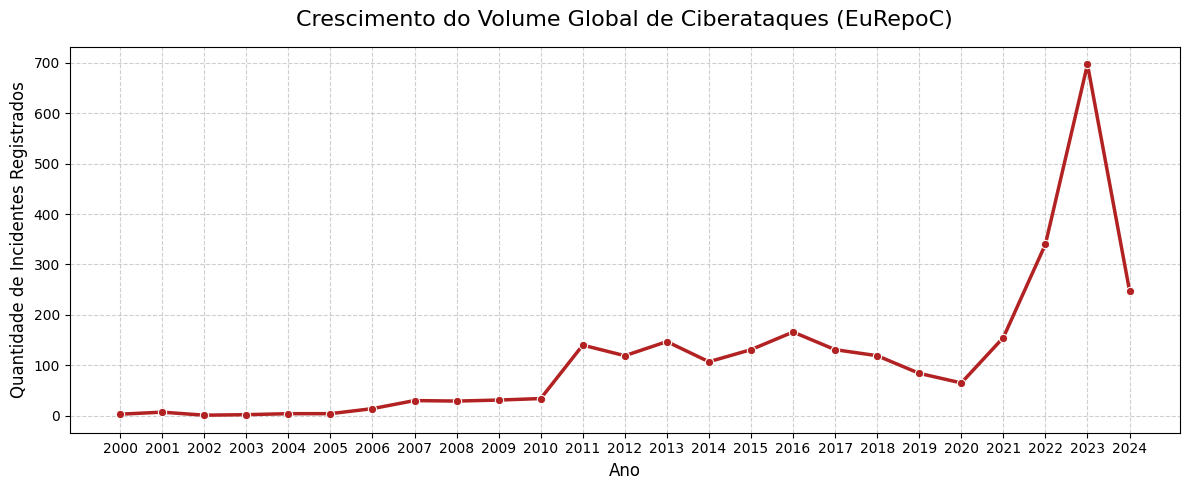

In [131]:
print("\nGerando visualizações exploratórias...")

# 1. Preparando a coluna de data
# Formato de data do Python e extraindo o Ano
dataset['start_date'] = pd.to_datetime(dataset['start_date'], errors='coerce')
dataset['Ano'] = dataset['start_date'].dt.year

# Criando uma coluna temporária com os nomes dos ataques limpos (apenas para o gráfico)
dataset['tipo_grafico'] = dataset['incident_type'].apply(lambda x: str(x).split(';')[0].split('&')[0].strip())

df_graficos = dataset[dataset['Ano'] >= 2000]

plt.figure(figsize=(12, 5))
ataques_por_ano = df_graficos['Ano'].value_counts().sort_index()

sns.lineplot(x=ataques_por_ano.index, y=ataques_por_ano.values, marker='o', color='firebrick', linewidth=2.5)

plt.title('Crescimento do Volume Global de Ciberataques (EuRepoC)', fontsize=16, pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Incidentes Registrados', fontsize=12)
plt.xticks(ataques_por_ano.index) # Garante que todos os anos apareçam no eixo X
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

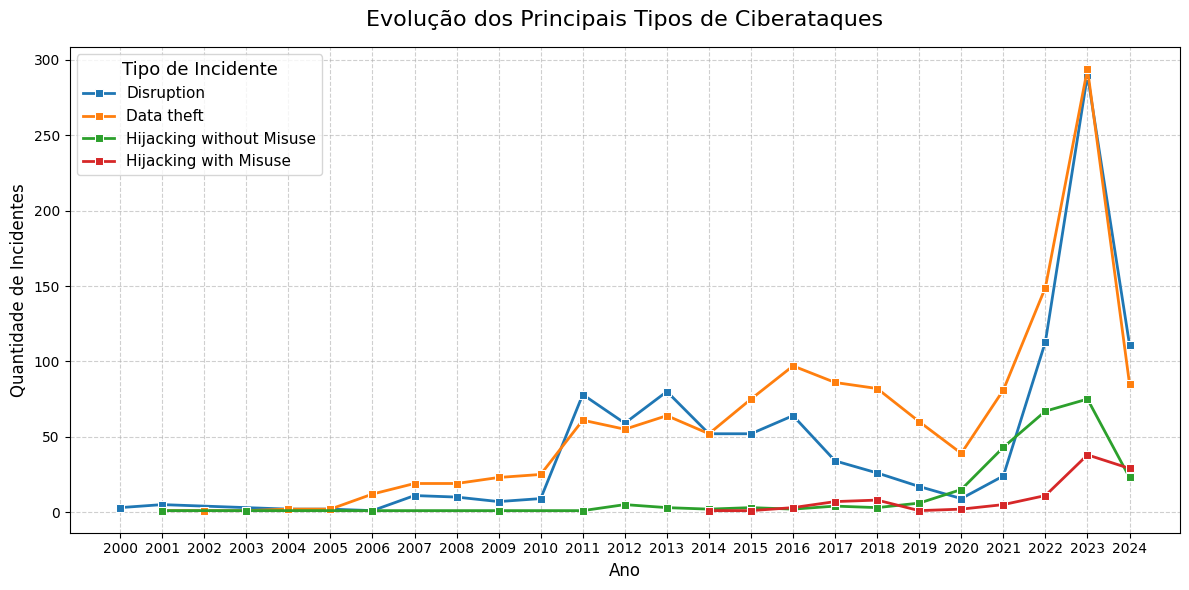

In [132]:
# Pegando apenas os 4 ataques mais comuns para o gráfico não virar uma "salada" de linhas
top_4_ataques = df_graficos['tipo_grafico'].value_counts().head(4).index
df_top_ataques = df_graficos[df_graficos['tipo_grafico'].isin(top_4_ataques)]

# Contando a quantidade de cada ataque por ano
evolucao_tipos = df_top_ataques.groupby(['Ano', 'tipo_grafico']).size().reset_index(name='Quantidade')

plt.figure(figsize=(12, 6))
sns.lineplot(data=evolucao_tipos, x='Ano', y='Quantidade', hue='tipo_grafico', marker='s', linewidth=2)

plt.title('Evolução dos Principais Tipos de Ciberataques', fontsize=16, pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Incidentes', fontsize=12)
plt.xticks(ataques_por_ano.index)
plt.legend(title='Tipo de Incidente', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Seleção de Colunas: Isolamos apenas as características (features) relevantes para o modelo

In [133]:
colunas_de_interesse = [
  'source_incident_detection_disclosure', 'incident_type', 'receiver_country',
  'receiver_region', 'receiver_category', 'receiver_category_subcode', 'initiator_country',
  'initiator_category', 'initiator_category_subcode', 'attribution_type',
  'attribution_basis', 'attributing_actor', 'attribution_it_company', 'attributing_country',
  'attributed_initiator', 'attributed_initiator_country', 'attributed_initiator_category'
]

df_modelo = dataset[colunas_de_interesse].copy()
df_modelo.head()

,source_incident_detection_disclosure,incident_type,receiver_country,receiver_region,receiver_category,receiver_category_subcode,initiator_country,initiator_category,initiator_category_subcode,attribution_type,attribution_basis,attributing_actor,attribution_it_company,attributing_country,attributed_initiator,attributed_initiator_country,attributed_initiator_category
0,Incident disclosed by attacker,Hijacking without Misuse,Australia,OC,Critical infrastructure,Finance,Not available,Non-state-group,Criminal(s),"Direct statement in media report (e.g., Reuter...",Attacker confirms,EMBARGO,Not available,Not available,EMBARGO,Not available,Non-state-group
1,Incident disclosed by authorities of victim state,Disruption; Hijacking with Misuse; Ransomware,France,EUROPE; NATO; EU(MS); WESTEU,State institutions / political system,Civil service / administration,Not available,Not available,NaN,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available
2,Incident disclosed by attacker,Hijacking with Misuse,Not available; Japan,- ASIA; SCS; NEA,End user(s) / specially protected groups - Cri...,- Critical Manufacturing,China,Unknown - not attributed,NaN,"Direct statement in media report (e.g., Reuter...",Attacker confirms,Not available,Not available,China,Not available,China,Unknown - not attributed
3,Incident disclosed by authorities of victim state,Disruption; Hijacking with Misuse,United States; Europe (region); Canada,NATO; NORTHAM - - NATO; NORTHAM,Critical infrastructure; Critical infrastructu...,Energy; Water; Food; Waste Water Management - ...,Russia,Non-state-group,Hacktivist(s),"Political statement / report (e.g., on governm...",Attribution by receiver government / state ent...,Cybersecurity and Infrastructure Security Agen...,Not available; Not available; Not available; N...,United States; United States; United States; U...,Not available; Not available; Not available; N...,Russia; Russia; Russia; Russia; Russia; Russia...,Non-state-group; Non-state-group; Non-state-gr...
4,Incident disclosed by authorities of victim state,Data theft,United States,NATO; NORTHAM,Critical infrastructure,Telecommunications,Not available,Not available,NaN,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available


## Removemos registros sem o tipo de incidente definido

In [134]:
df_modelo = df_modelo.dropna(subset=['incident_type'])
df_modelo = df_modelo[df_modelo['incident_type'] != 'Not available']

print("Coluna alvo tratada")
print(df_modelo['incident_type'])

Coluna alvo tratada
0                                Hijacking without Misuse
1           Disruption; Hijacking with Misuse; Ransomware
2                                   Hijacking with Misuse
3                       Disruption; Hijacking with Misuse
4                                              Data theft
5                                              Data theft
6                                Hijacking without Misuse
7                                Hijacking without Misuse
8           Data theft; Hijacking with Misuse; Ransomware
9                                              Data theft
10                                  Hijacking with Misuse
11          Disruption; Hijacking with Misuse; Ransomware
12          Disruption; Hijacking with Misuse; Ransomware
13          Disruption; Hijacking with Misuse; Ransomware
14          Disruption; Hijacking with Misuse; Ransomware
15                               Hijacking without Misuse
16             Data theft & Doxing; Hijacking with M

## Agrupamos categorias complexas e removemos ataques extremamente raros  para evitar ruído matemático e focar nas ameaças estatisticamente relevantes


In [135]:
# Simplificando as classes
df_modelo['incident_type'] = df_modelo['incident_type'].apply(lambda x: str(x).split(';')[0].strip())
df_modelo['incident_type'] = df_modelo['incident_type'].apply(lambda x: str(x).split('&')[0].strip())

# Remover classes raras
contagem_classes = df_modelo['incident_type'].value_counts()
classes_frequentes = contagem_classes[contagem_classes >= 5].index
df_modelo = df_modelo[df_modelo['incident_type'].isin(classes_frequentes)]

print("Distribuição das novas classes simplificadas:")
print(df_modelo['incident_type'].value_counts())

Distribuição das novas classes simplificadas:
incident_type
Data theft                  1430
Disruption                  1065
Hijacking without Misuse     279
Hijacking with Misuse        111
Name: count, dtype: int64


## One-Hot Encoding




In [136]:
X = df_modelo.drop(columns=['incident_type'])
y = df_modelo['incident_type']

X = X.fillna('Desconhecido').replace('Not available', 'Desconhecido')
X = X.astype(str)

X_codificado = pd.get_dummies(X, drop_first=True)
X_codificado = X_codificado.fillna(0) # Garantia extra


print(f"Tamanho após pré-processamento (X): {X_codificado.shape}")

X_treino, X_teste, y_treino, y_teste = train_test_split(X_codificado, y, test_size=0.2, random_state=42)

Tamanho após pré-processamento (X): (2885, 5245)


## GridSearch e Prevenção de Vazamento de Dados

In [137]:
print("Iniciando o GridSearch... Treinando múltiplos modelos...\n")

# Valores de K a testar De 1 a 11 (ímpares)
parametros_para_testar = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

Iniciando o GridSearch... Treinando múltiplos modelos...



## Validação Cruzada e Execução do KNN

In [143]:
knn_base = KNeighborsClassifier()

# Configurando teste automático
grid_search = GridSearchCV(
    estimator= knn_base,
    param_grid= parametros_para_testar,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_treino, y_treino)

# Resultados do melhor vizinho
melhor_vizinho = grid_search.best_params_['n_neighbors']
melhor_peso = grid_search.best_params_['weights']

melhor_modelo = grid_search.best_estimator_

y_pred_teste_simples = melhor_modelo.predict(X_teste)

print(f"O melhor número de vizinhos (K) é: {melhor_vizinho}")
print(f"O melhor sistema de pesos é: {melhor_peso}")
print(f"Acurácia no Teste Simples: {accuracy_score(y_teste, y_pred_teste_simples):.8f}")
print("-" * 50)

print("\n")

y_pred_cross_val = cross_val_predict(melhor_modelo, X_codificado, y, cv=5) # Válidação cruzada

# Avaliação Final do KNN
print("\n=== RESULTADOS DO MODELO OTIMIZADO ===")
print(f"Acurácia na Validação Cruzada: {accuracy_score(y, y_pred_cross_val):.8f}")
print("\nRelatório de Classificação Detalhado:\n")
print(classification_report(y, y_pred_cross_val))

O melhor número de vizinhos (K) é: 7
O melhor sistema de pesos é: uniform
Acurácia no Teste Simples: 0.66724437
--------------------------------------------------


--------------------------------------------------

=== RESULTADOS DO MODELO OTIMIZADO ===
Acurácia na Validação Cruzada: 0.60623917

Relatório de Classificação Detalhado:

                          precision    recall  f1-score   support

              Data theft       0.62      0.72      0.67      1430
              Disruption       0.61      0.61      0.61      1065
   Hijacking with Misuse       0.51      0.19      0.28       111
Hijacking without Misuse       0.40      0.19      0.26       279

                accuracy                           0.61      2885
               macro avg       0.54      0.43      0.45      2885
            weighted avg       0.59      0.61      0.59      2885



## Matriz de Confusão

A Matriz de Confusão é a apresentação executiva do nosso modelo.
* **Diagonal Principal (Azul Escuro):** Representa os nossos acertos categóricos.
* **Fora da Diagonal:** Mostra onde o modelo está se confundindo. Devido ao desbalanceamento natural da base (muitos casos de *Data theft* e poucos de *Hijacking*), é esperado que o modelo favoreça as classes majoritárias em situações de dúvida.

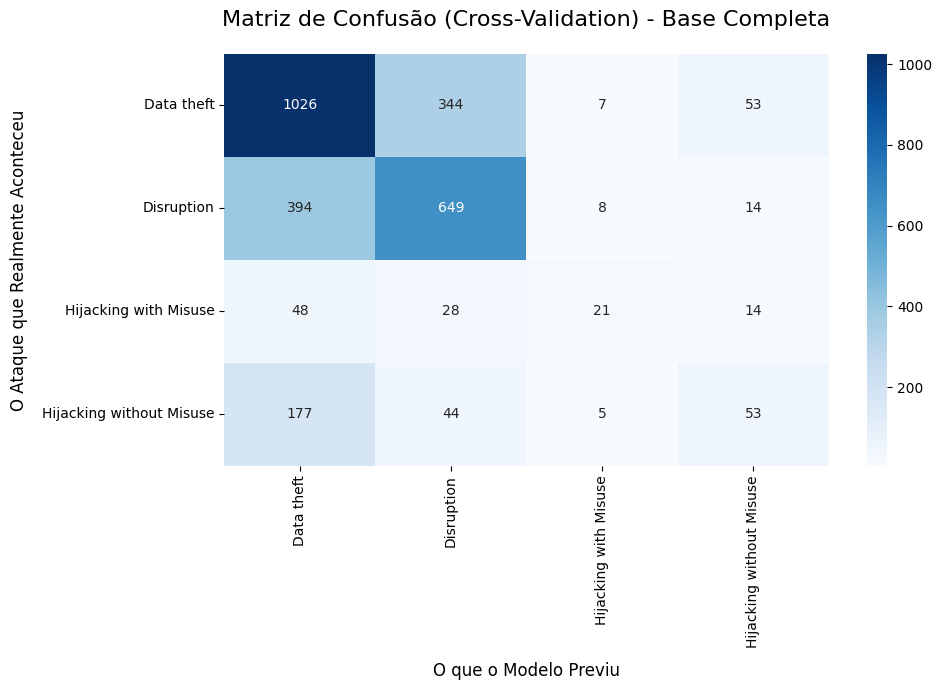

In [139]:
matriz_confusao = confusion_matrix(y, y_pred_cross_val)

nomes_das_classes = melhor_modelo.classes_

plt.figure(figsize=(10, 7))

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_das_classes, yticklabels=nomes_das_classes)
plt.title('Matriz de Confusão (Cross-Validation) - Base Completa', fontsize=16, pad=20)
plt.xlabel('O que o Modelo Previu', fontsize=12, labelpad=10)
plt.ylabel('O Ataque que Realmente Aconteceu', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()